In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv("parkinsons_updrs.csv")

In [ ]:
data.head()

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


In [ ]:
(data.columns)

Index(['subject#', 'age', 'sex', 'test_time', 'motor_UPDRS', 'total_UPDRS',
       'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP',
       'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE'],
      dtype='object')

In [ ]:
# Random forest regression model

In [ ]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Load dataset
df = pd.read_csv('parkinsons_updrs.csv')

In [ ]:
# Explore the data
print(df.head())
print(df.columns)

   subject#  age  sex  test_time  motor_UPDRS  total_UPDRS  Jitter(%)  \
0         1   72    0     5.6431       28.199       34.398    0.00662   
1         1   72    0    12.6660       28.447       34.894    0.00300   
2         1   72    0    19.6810       28.695       35.389    0.00481   
3         1   72    0    25.6470       28.905       35.810    0.00528   
4         1   72    0    33.6420       29.187       36.375    0.00335   

   Jitter(Abs)  Jitter:RAP  Jitter:PPQ5  ...  Shimmer(dB)  Shimmer:APQ3  \
0     0.000034     0.00401      0.00317  ...        0.230       0.01438   
1     0.000017     0.00132      0.00150  ...        0.179       0.00994   
2     0.000025     0.00205      0.00208  ...        0.181       0.00734   
3     0.000027     0.00191      0.00264  ...        0.327       0.01106   
4     0.000020     0.00093      0.00130  ...        0.176       0.00679   

   Shimmer:APQ5  Shimmer:APQ11  Shimmer:DDA       NHR     HNR     RPDE  \
0       0.01309        0.01662      

In [ ]:
df['mild_park'] = df['total_UPDRS'].apply(lambda x: 1 if x > 32 else 0)
df.mild_park.value_counts().reset_index()

,mild_park,count
0,0,3800
1,1,2075


In [ ]:
df.groupby('mild_park').agg({'total_UPDRS':'max'}).reset_index()

,mild_park,total_UPDRS
0,0,32.000
1,1,54.992


In [ ]:
# Choose target and features
# Let's predict 'total_UPDRS' using all other features except subject
X = df.drop(['total_UPDRS', 'subject#'], axis=1)
y = df['mild_park']

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
# Fit Random Forest Regressor
# Initialize and train model
rf = RandomForestClassifier(n_estimators=150, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=150, random_state=42)

In [ ]:
# Predict
y_pred = rf.predict(X_test)

In [ ]:
# Evaluate
print("R² score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R² score: 1.0
MSE: 0.0


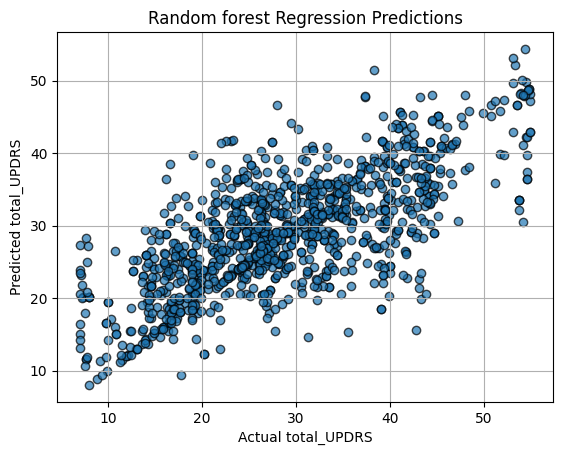

In [ ]:
# Optional: Plot predictions
plt.scatter(y_test, y_pred, alpha=0.7, edgecolor='k')
plt.xlabel("Actual total_UPDRS")
plt.ylabel("Predicted total_UPDRS")
plt.title("Random forest Regression Predictions")
plt.grid(True)
plt.show()

In [ ]:
# Naive bayes regression model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import mean_squared_error
import numpy as np


In [ ]:
# Drop non-feature columns
X = df.drop(columns=["subject#", "motor_UPDRS", "total_UPDRS"])
y = df["total_UPDRS"].values

In [ ]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Discretize the target (total_UPDRS) into bins
n_bins = 15
discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='uniform')
y_train_binned = discretizer.fit_transform(y_train.reshape(-1, 1)).ravel()


In [ ]:
# Train Gaussian Naive Bayes on the binned targets
gnb = GaussianNB()
gnb.fit(X_train, y_train_binned)


GaussianNB()

In [ ]:
# Predict probabilities for each bin on test set
probas = gnb.predict_proba(X_test)

In [ ]:
# Compute bin centers to get expected continuous prediction
bin_edges = discretizer.bin_edges_[0]
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
y_pred = np.dot(probas, bin_centers)


In [ ]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mse

70.59607605492157

In [ ]:
# Evaluate
print("R² score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R² score: 0.3629262951431713
MSE: 70.59607605492157


In [ ]:
# XGBoost regression model

In [ ]:
from xgboost import XGBRegressor

In [ ]:
# Initialize XGBoost regressor
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)


In [ ]:
# Train the model
xgb_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [ ]:
# Predict on test data
y_pred_xgb = xgb_model.predict(X_test)


In [ ]:
# Evaluate the model
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
mse_xgb

1.8472298471979358

In [ ]:
# Evaluate
print("R² score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R² score: 0.3629262951431713
MSE: 70.59607605492157


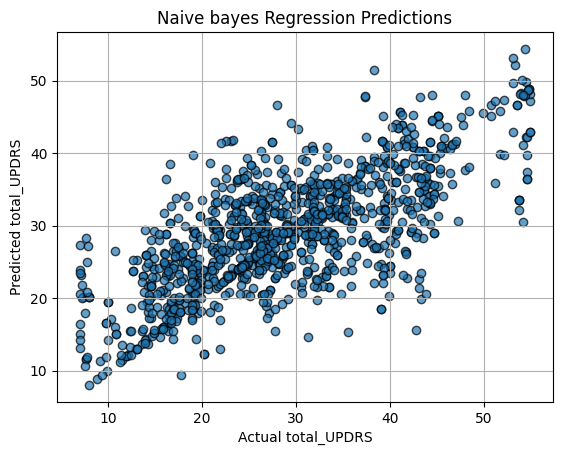

In [ ]:
# Optional: Plot predictions
plt.scatter(y_test, y_pred, alpha=0.7, edgecolor='k')
plt.xlabel("Actual total_UPDRS")
plt.ylabel("Predicted total_UPDRS")
plt.title("Naive bayes Regression Predictions")
plt.grid(True)
plt.show()

In [ ]:
# KNN regression model

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [ ]:
# Load dataset
df = pd.read_csv("parkinsons_updrs.csv")


In [ ]:
# Prepare features and target
X = df.drop(columns=["subject#", "motor_UPDRS", "total_UPDRS"])
y = df["total_UPDRS"]


In [ ]:
# Step 3: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [ ]:
# Create KNN Regressor model
knn_model = KNeighborsRegressor(n_neighbors=5)  # You can tune n_neighbors
knn_model.fit(X_train, y_train)


KNeighborsRegressor()

In [ ]:
# Predict
y_pred = knn_model.predict(X_test)


In [ ]:
# Evaluate
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (KNN): {mse:.2f}")


Mean Squared Error (KNN): 53.97


In [ ]:
# Evaluate
print("R² score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R² score: 0.5129205243996592
MSE: 53.974759030433695


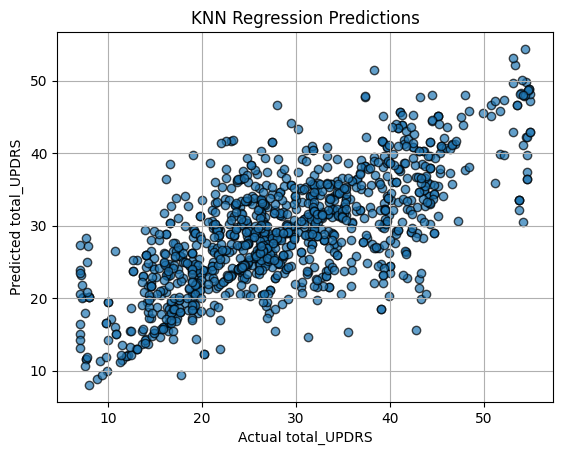

In [ ]:
# Optional: Plot predictions
plt.scatter(y_test, y_pred, alpha=0.7, edgecolor='k')
plt.xlabel("Actual total_UPDRS")
plt.ylabel("Predicted total_UPDRS")
plt.title("KNN Regression Predictions")
plt.grid(True)
plt.show()

In [ ]:
# ANN regression model

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
# Step 1: Load the dataset
df = pd.read_csv("parkinsons_updrs.csv")

In [ ]:
# Step 2: Prepare features and target
X = df.drop(columns=["subject#", "motor_UPDRS", "total_UPDRS"])
y = df["total_UPDRS"]

In [ ]:
# Step 3: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Step 4: Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# Step 5: Build the ANN model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer for regression
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Step 6: Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])


In [ ]:
# Step 7: Train the model
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=16, validation_split=0.2, verbose=0)

In [ ]:
# Step 8: Predict on test data
y_pred = model.predict(X_test_scaled).flatten()


37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
# Step 9: Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (ANN): {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Squared Error (ANN): 25.07
R² Score: 0.77


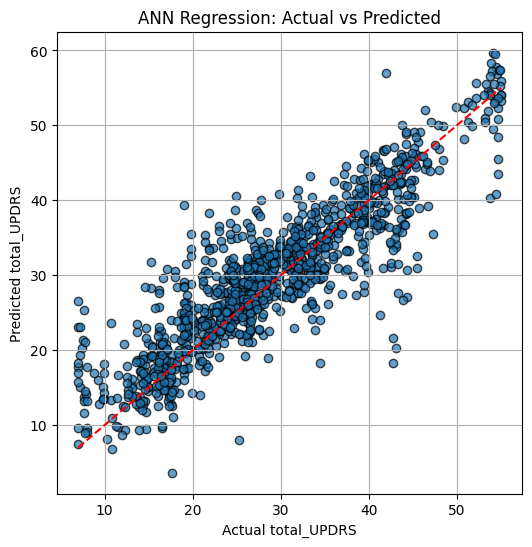

In [ ]:
# Step 10: Plot predictions
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual total_UPDRS")
plt.ylabel("Predicted total_UPDRS")
plt.title("ANN Regression: Actual vs Predicted")
plt.grid(True)
plt.show()